# Daily Behaviour Clustering with t‑SNE and DBSCAN

This notebook demonstrates how to cluster daily bike sharing data using the density-based clustering algorithm DBSCAN.  We first load the daily dataset (`day.csv`), perform feature engineering and standardization, explore the data using a k‑distance graph and t‑SNE, and then apply DBSCAN.  The goal is to identify dense behavioural patterns (e.g., high-demand days, low-demand days) and detect noise points that may correspond to unusual events.


## Dataset and feature selection

We use the **daily** bike sharing dataset (`day.csv`) which contains 731 records (one per day).  Each record includes environmental factors (temperature, wind speed, humidity, etc.), calendar variables (season, month, working day indicator), and counts of casual and registered users.  For clustering daily behaviour, we select the following features:

- `temp` – normalized temperature in °C.
- `windspeed` – normalized wind speed.
- `workingday` – whether the day is a working day (1) or not (0).
- `casual` – count of casual riders.
- `registered` – count of registered riders.

We apply a logarithmic transformation to `casual` and `registered` to reduce skewness.  After that, we standardize all features so they contribute equally to distance calculations.


In [6]:
import sys
print(sys.executable)

/opt/homebrew/Cellar/jupyterlab/4.4.3_3/libexec/bin/python


In [7]:
import sys
!{sys.executable} -m pip install pandas

  Using cached pandas-3.0.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.3-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached pandas-3.0.1-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)
Using cached numpy-2.4.3-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


In [14]:
import sys
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install matplotlib

In [4]:
!pip install pandas

In [8]:
import pandas as pd
import numpy as np

# Load the daily dataset.  Adjust the path if needed.
data = pd.read_csv('day.csv')

# Display the first few rows to inspect the structure
data.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [11]:
# Select base features
features = ['temp', 'windspeed', 'workingday', 'casual', 'registered']

# Log transform count variables to reduce skewness
data['casual_log'] = np.log1p(data['casual'])
data['registered_log'] = np.log1p(data['registered'])

# Construct the feature matrix with transformed counts
X = data[['temp', 'windspeed', 'workingday', 'casual_log', 'registered_log']]

# Standardize features so each contributes equally to distance
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


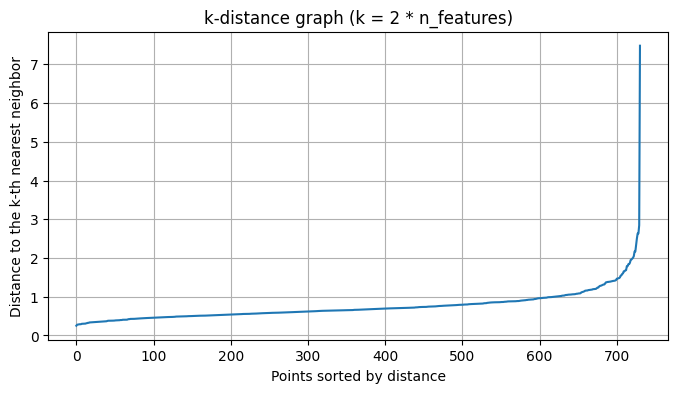

In [15]:
# Plot the k-distance graph to choose eps for DBSCAN
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Set min_samples as twice the number of features
min_samples_estimate = 2 * X.shape[1]

neighbors = NearestNeighbors(n_neighbors=int(min_samples_estimate))
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, int(min_samples_estimate) - 1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('k-distance graph (k = 2 * n_features)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to the k-th nearest neighbor')
plt.grid(True)
plt.show()

# After plotting, inspect the curve for an elbow point.  This value of distance
# will be used as the eps parameter for DBSCAN.


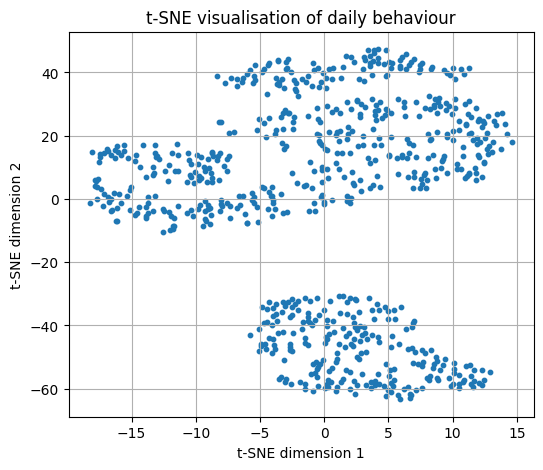

In [16]:
# Perform t-SNE to visualise potential clusters
from sklearn.manifold import TSNE

# Use a moderate perplexity.  t-SNE is stochastic; random_state ensures reproducibility.
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10)
plt.title('t-SNE visualisation of daily behaviour')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True)
plt.show()

# Look for visually separated clusters.  If distinct clouds appear, DBSCAN is likely appropriate.


## Choosing DBSCAN parameters

The DBSCAN algorithm requires two key parameters:

- **`eps` (epsilon)** – defines the radius of the neighborhood for clustering.  Use the elbow point from the k-distance graph as a guideline for choosing `eps`.The epsilon parameter was selected from the k-distance graph by identifying the elbow point at approximately 1.4, which represents the transition from dense regions to sparse regions.
- **`min_samples`** – minimum number of points required to form a dense region.  A common heuristic is to set `min_samples` to twice the number of features; in this case, that is 10.  You may adjust it based on domain knowledge.

After examining the k-distance plot, set `eps` in the next cell and run the clustering.  Note that changing `eps` or `min_samples` will affect the number and composition of clusters.


In [19]:
# Apply DBSCAN clustering
from sklearn.cluster import DBSCAN

# TODO: Replace the value below with your chosen eps from the k-distance graph.
eps_value = 1.4  # <-- Set your chosen epsilon here
min_samples_value = int(2 * X.shape[1])  # default to 2 * n_features

# Fit DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)

# Assign cluster labels back to the data
data['cluster'] = labels

# Summarise cluster sizes (including noise labelled as -1)
cluster_counts = data['cluster'].value_counts()
print('Cluster counts (including noise):')
print(cluster_counts)

# Compute mean values of key variables per cluster
summary = data.groupby('cluster')[['temp', 'windspeed', 'casual', 'registered']].mean()
print('Cluster summaries (mean values):')
print(summary)


Cluster counts (including noise):
cluster
 1    494
 0    226
-1     11
Name: count, dtype: int64
Cluster summaries (mean values):
             temp  windspeed       casual   registered
cluster                                               
-1       0.285725   0.301096   107.727273   686.000000
 0       0.484783   0.188015  1397.300885  3003.323009
 1       0.504904   0.189154   613.445344  4020.981781


DBSCAN identified a small set of anomalous days characterized by low temperature and low rental activity.

**Cluster 0 (226 days)**
temp → moderate (0.48)

casual → very high (1397)

registered → moderate

**This cluster represents leisure-oriented usage patterns.**


**Cluster 1 (494 days)**
temp → similar (0.50)

casual → moderate

registered → very high (4020)

**This cluster corresponds to regular commuter-driven demand.**